In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs 
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import AutoMinorLocator
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
from zhiyi.plot.Plot_2D import Plot_2D
import netCDF4 as nc
from glob import glob
print('done')

done


In [ ]:
file_paths_BB = sorted(glob(
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/MUSICAv0_ne60_production.cam.h3.2018-05-??-00000.nc"))
combined_BB = xr.open_mfdataset(file_paths_BB, combine='by_coords')
daily = combined_BB.resample(time="1D").mean(dim="time")
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"


In [7]:
daily

<xarray.Dataset> Size: 14GB
Dimensions:     (time: 30, ncol: 194402, lev: 32, ilev: 33)
Coordinates:
  * lev         (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev        (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time        (time) datetime64[ns] 240B 2018-05-02 2018-05-03 ... 2018-05-31
Dimensions without coordinates: ncol
Data variables: (12/48)
    lat         (time, ncol) float64 47MB dask.array<chunksize=(1, 194402), meta=np.ndarray>
    lon         (time, ncol) float64 47MB dask.array<chunksize=(1, 194402), meta=np.ndarray>
    area        (time, ncol) float64 47MB dask.array<chunksize=(1, 194402), meta=np.ndarray>
    hyam        (time, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    hybm        (time, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    hyai        (time, ilev) float64 8kB dask.array<chunksize=(1, 33), meta=np.ndarray>
    ...          ...
    RELHUM      (time, lev, ncol) float32 747MB dask.array<chunksize=(1, 32, 194402), meta=np.ndarray>
    SVOC        (time, lev, ncol) float32 747MB dask.array<chunksize=(1, 32, 194402), meta=np.ndarray>
    T           (time, lev, ncol) float32 747MB dask.array<chunksize=(1, 32, 194402), meta=np.ndarray>
    U           (time, lev, ncol) float32 747MB dask.array<chunksize=(1, 32, 194402), meta=np.ndarray>
    V           (time, lev, ncol) float32 747MB dask.array<chunksize=(1, 32, 194402), meta=np.ndarray>
    Z3          (time, lev, ncol) float32 747MB dask.array<chunksize=(1, 32, 194402), meta=np.ndarray>
Attributes:
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              MUSICAv0_ne60_production
    logname:           zhiyisong
    host:              ln01
    initial_file:      /work/n02/n02/zhiyisong/CESM/archive/MUSICAv0_ne60_spi...
    topography_file:   /work/n02/n02/zhiyisong/MUSICARE/ne0np4.UK_ne60/topo/t...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

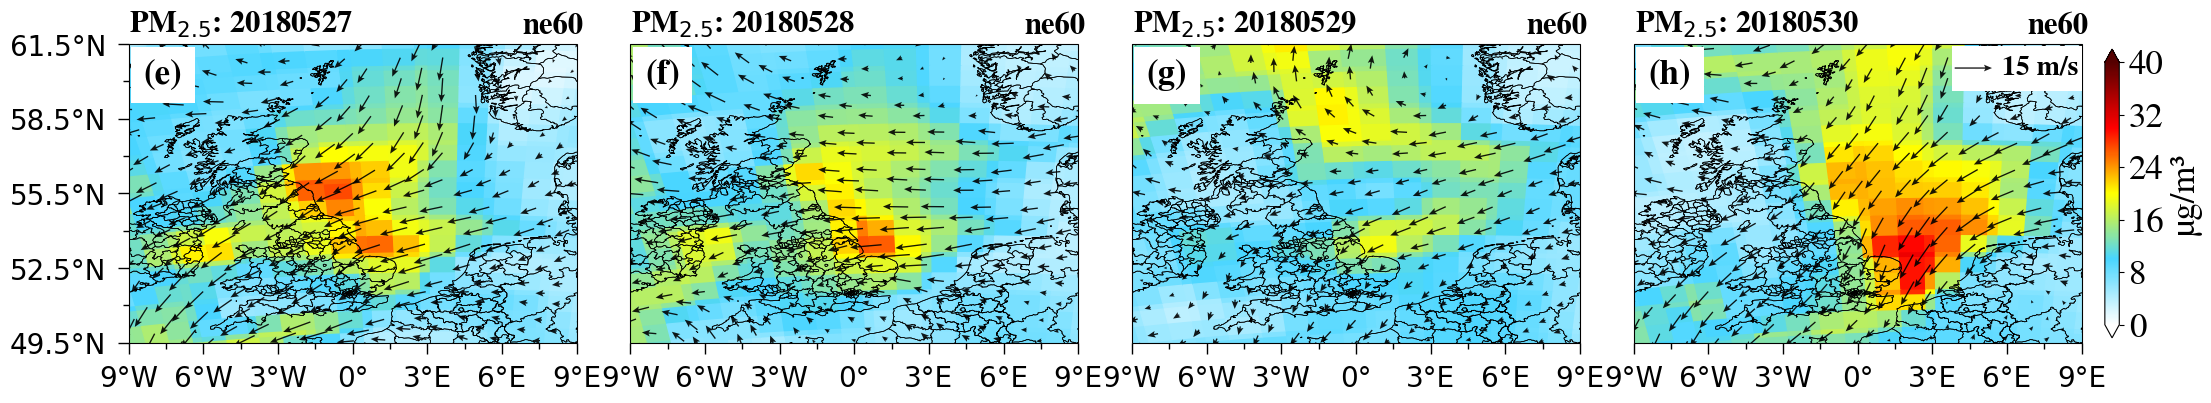

In [ ]:
dates = [ '2018-05-27', '2018-05-28', '2018-05-29', '2018-05-30']
plot_settings = [
    (daily.sel(time=dt)['PM25'].isel(lev=-1) * 1e9,
        dt, "",
        0, 40,
        'µg/m³'
    )
    for dt in dates]

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]
u = daily['U'].isel(lev=-1).values
v = daily['V'].isel(lev=-1).values 
step = 2
lon_plot = lon_scrip[::step]
lat_plot = lat_scrip[::step]

fig, axs = plt.subplots(1, 4, figsize=(30, 15), subplot_kw={'projection': ccrs.PlateCarree()})
for i, (data, date_str, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = axs.flat[i]
    u_day = daily.sel(time=date_str)['U'].isel(lev=-1).values
    v_day = daily.sel(time=date_str)['V'].isel(lev=-1).values
    u_plot = u_day[::step]
    v_plot = v_day[::step]
    
    p = Plot_2D(
        data,
        scrip_file=scrip_filename, pretty_tick=True,
        lon_range=[-9, 9],
        lat_range=[49.5, 61.5],
        # lon_range=[-8.5, 9],
        # lat_range=[49.5, 61.5],
        # lon_range=[-9, 2],
        # lat_range=[49.5, 61.5],
        # lon_range=[-15, 8],
        # lat_range=[45, 62],
        lon_interval=3,
        lat_interval=3,
        resolution="10m",
        country=True, state=True, title=title,
        title_bold=True, unit=unit, 
        nticks=6,
        title_size=30,
        label_size=22,
        cmax=vmax, cmin=vmin, 
        # feature_line_lw=0.45,
        # grid_line=True,
        lonlat_line=False,
        shrink=0.85,
        pad=0.055,
        unit_offset=[0.05, 0],
        ax=ax,
        colorbar=False
    )    
    if hasattr(p, 'cb'):
        p.cb.ax.tick_params(labelsize=20)
        for txt in p.cb.ax.texts:
            txt.set_fontsize(20)

    font_prop = FontProperties(size=20, weight='bold')
    q = ax.quiver(
            lon_plot, lat_plot, u_plot, v_plot,
            scale=180, color='k', width=0.003, alpha=0.9,
            headaxislength=5, headwidth=5, headlength=6, zorder=9,
            transform=ccrs.PlateCarree())
    if i == 3:
        rect = Rectangle(
            (0.711, 0.843), 
            0.3, 0.15,
            transform=ax.transAxes,
            facecolor='white',
            edgecolor='none',
            zorder=9
        )
        ax.add_patch(rect)    
        qk = ax.quiverkey(q, X=0.8, Y=0.92, U=15, label='15 m/s', 
                     labelpos='E', coordinates='axes', 
                     fontproperties=font_prop, zorder=9)
        qk.text.set_bbox(dict(facecolor='white', edgecolor='none', pad=0.5))

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=20, pad=12, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1 )

    if i == 0:
        ax.set_ylabel("", fontsize=40, labelpad=15, weight='bold')
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=12, length=8, width=1 )
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1 )
    elif i == 3:
        ax.set_ylabel("", fontsize=18, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=True)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=12, length=8, width=1, labelleft=False, labelright=False, left=False, right=False)
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1, labelleft=False, labelright=False, left=False, right=False)
    else:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

    ax.set_xlabel("", fontsize=18)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.xaxis.set_tick_params( labelsize=20, pad=8)  
    ax.yaxis.set_tick_params(  labelsize=20, pad=8)

fig.subplots_adjust(wspace=0.12,
                    hspace=0.05,)


letters = ['(e)', '(f)', '(g)', '(h)']
for i, ax in enumerate(axs.flat):
    ax.text(
            0.033, 0.95,
            # 0.041, 0.94, 
            letters[i], transform=ax.transAxes, zorder=10,
            fontsize=25, va='top', 
            ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.36',  alpha=1))
    
    day = dates[i].split('-')[-1]
    title_str = f"PM$_{{2.5}}$: 201805{day}"            
    ax.text(
            0.002, 1.015,                                
            title_str,
            transform=ax.transAxes,
            fontsize=22, va='bottom', ha='left',
            weight='bold',
            zorder=10)
    title_str = r'ne60'           
    ax.text(
            0.88, 1.015,                               
            title_str,
            transform=ax.transAxes,
            fontsize=22, va='bottom', ha='left',
            weight='bold', 
            zorder=10)

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"

def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.1f}°N"
    else:
        return f"{abs(y):.1f}°S"

for _ax in axs.flat:
    _ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    _ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

cb = fig.colorbar(p.im, 
                  ax=axs,
                  orientation='vertical', shrink=0.25, pad=0.01,
                  extend='both',
                  ticks=np.arange(0, 42, 8) 
                  )
cb.ax.tick_params(labelsize=25)
cb.set_label('µg/m³', fontsize=25)                   
cb.ax.yaxis.set_label_position('right')             
cb.ax.yaxis.set_label_coords(4.5, 0.5) 

